In [69]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
import torch
import torch.nn as nn


In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
layal_vs_fery_df = pd.read_csv('/content/drive/MyDrive/tennis_events_dataframes/event_detections_dataset/Layal_vs_Fery.csv')
layal_vs_hsu_df = pd.read_csv('/content/drive/MyDrive/tennis_events_dataframes/event_detections_dataset/Layal_vs_Hsu.csv')
layal_vs_martin_df = pd.read_csv('/content/drive/MyDrive/tennis_events_dataframes/event_detections_dataset/Layal_vs_Martin.csv')
novak_vs_thiem_df = pd.read_csv('/content/drive/MyDrive/tennis_events_dataframes/event_detections_dataset/Novak_vs_Thiem.csv')
daderi_vs_coria_df = pd.read_csv('/content/drive/MyDrive/tennis_events_dataframes/event_detections_dataset/daderi_vs_coria.csv')
stan_vs_rafa_df = pd.read_csv('/content/drive/MyDrive/tennis_events_dataframes/event_detections_dataset/stan_vs_rafa.csv')
rafa_vs_medvedev_df = pd.read_csv('/content/drive/MyDrive/tennis_events_dataframes/event_detections_dataset/rafa_vs_medvedev.csv')
paolini_vs_pegula_df = pd.read_csv('/content/drive/MyDrive/tennis_events_dataframes/event_detections_dataset/paolini_vs_pegula.csv')
federer_vs_rafa_df = pd.read_csv('/content/drive/MyDrive/tennis_events_dataframes/event_detections_dataset/federer_vs_rafa.csv')



In [167]:
# Columns identified to potentially have NaN values that need filling
columns_to_fill = ['velocity_mean', 'velocity_std', 'acc_mean', 'acc_std']

# Iterate through the initial DataFrames and fill NaN values
for df in [layal_vs_fery_df, layal_vs_hsu_df, layal_vs_martin_df]:
    for col in columns_to_fill:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mean())

In [168]:
train_df = pd.concat([ layal_vs_hsu_df , layal_vs_martin_df])
valid_df = layal_vs_fery_df

In [169]:
train_df.head()

,Unnamed: 0,frame,ball_x,ball_y,player_1_x,player_1_y,player_2_x,player_2_y,top_left_x,top_left_y,...,ball_acc,ball_direction,dir_sin,dir_cos,velocity_mean,velocity_std,acc_mean,acc_std,nearest_player_to_ball,nearest_player_rate
0,0,768,376.664337,1349.013428,144.13509,197.93105,144.13509,197.93105,50.253920,299.36017,...,8.313788,1.003306,0.843253,0.537517,62.786475,21.038626,16.762483,10.194065,1174.334068,14.753833
1,1,769,388.912445,1368.228149,143.61717,204.71611,143.61717,204.71611,50.064570,299.34260,...,9.653440,0.267170,0.264003,0.964522,62.786475,21.038626,16.762483,10.194065,1189.087901,-5.678915
2,2,770,394.435852,1338.015503,142.73872,202.60268,142.73872,202.60268,49.336830,299.99440,...,11.117139,-1.189498,-0.928182,0.372125,15.801801,10.257439,10.579362,1.864854,1162.976238,-24.489297
3,3,771,401.813538,1302.720215,144.28317,192.07745,144.28317,192.07745,50.165154,299.31573,...,10.472653,-1.392321,-0.984115,0.177529,23.090301,17.043953,11.882344,2.141608,1140.109307,-73.313248
4,4,772,409.104279,1192.485596,146.13560,210.74516,146.13560,210.74516,49.547890,299.32700,...,13.339791,-1.384047,-0.982613,0.185666,34.147335,20.171794,11.194419,3.284203,1016.349743,-47.618973


In [170]:
FEATURE_COLUMNS = [

    # Ball trajectory
    "y_ball_smooth",
    "x_ball_smooth",
    "vx_ball",
    "vy_ball",
    "ax_ball",
    "ay_ball",
    "ball_speed",
    "ball_acc" ,
    "dir_sin",
    "dir_cos",
    "velocity_mean" ,
    "velocity_std" ,
    "acc_mean" ,
    "acc_std" ,
    # Player interaction
    "nearest_player_to_ball",
    "nearest_player_rate",

    #court
    "top_left_x" ,
    "top_left_y" ,
    "bottom_left_x" ,
    "bottom_left_y" ,
    "bottom_right_x" ,
    "bottom_right_y" ,
    "top_right_x" ,
    "top_right_y" ,

]

In [171]:
len(FEATURE_COLUMNS)

24

In [172]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3424 entries, 0 to 2212
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              3424 non-null   int64  
 1   frame                   3424 non-null   int64  
 2   ball_x                  3424 non-null   float64
 3   ball_y                  3424 non-null   float64
 4   player_1_x              3424 non-null   float64
 5   player_1_y              3424 non-null   float64
 6   player_2_x              3424 non-null   float64
 7   player_2_y              3424 non-null   float64
 8   top_left_x              3424 non-null   float64
 9   top_left_y              3424 non-null   float64
 10  top_right_x             3424 non-null   float64
 11  top_right_y             3424 non-null   float64
 12  bottom_left_x           3424 non-null   float64
 13  bottom_left_y           3424 non-null   float64
 14  bottom_right_x          3424 non-null   float

In [173]:
train_df.label.value_counts()

,count
label,
no_event,3286
ball_hit,71
ball_bounced,67


In [174]:
label2id = {
    "no_event": 0,
    "ball_hit": 1,
    "ball_bounced": 2,
}
id2label = {
    0: "no_event",
    1: "ball_hit",
    2: "ball_bounced",
}

In [175]:
train_df['label'] = train_df['label'].map(label2id)
valid_df['label'] = valid_df['label'].map(label2id)

In [176]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_df[FEATURE_COLUMNS] = scaler.fit_transform(
    train_df[FEATURE_COLUMNS]
)

valid_df[FEATURE_COLUMNS] = scaler.transform(
    valid_df[FEATURE_COLUMNS]
)

In [177]:
class TennisEventDataset(Dataset):

    def __init__(
        self,
        dataframe: pd.DataFrame,
        feature_columns,
        label_column="label",
        window_size=15,
        event_tolerance=2,
        negative_ratio=1.0,
        random_state=42,
    ):

        assert window_size % 2 == 1

        self.df = dataframe.reset_index(drop=True)

        self.features = feature_columns
        self.label_column = label_column

        self.window_size = window_size
        self.radius = window_size // 2

        self.event_tolerance = event_tolerance

        rng = np.random.default_rng(random_state)

        self.samples = []


        # Event Frames

        event_frames = np.where(
            self.df[label_column].values != 0
        )[0]

        # Positive samples

        for event_frame in event_frames:

            label = int(self.df.loc[event_frame, label_column])

            for offset in range(
                -event_tolerance,
                event_tolerance + 1,
            ):

                center = event_frame + offset

                if center < self.radius:
                    continue

                if center >= len(self.df) - self.radius:
                    continue

                # Sample weight
                sigma = event_tolerance / 2

                weight = np.exp(-(offset**2) / (2 * sigma**2))

                self.samples.append(
                    (
                        center,
                        label,
                        weight,
                    )
                )


        # Negative candidates
        safe_margin = self.radius + event_tolerance

        negative_candidates = []

        for center in range(
            self.radius,
            len(self.df) - self.radius,
        ):

            if self.df.loc[center, label_column] != 0:
                continue

            if len(event_frames):

                nearest_event = np.min(
                    np.abs(event_frames - center)
                )

                if nearest_event <= safe_margin:
                    continue

            negative_candidates.append(center)


        # Sample negatives
        positive_count = len(self.samples)

        desired_negative_count = int(
            positive_count * negative_ratio
        )

        desired_negative_count = min(
            desired_negative_count,
            len(negative_candidates),
        )

        negative_centers = rng.choice(
            negative_candidates,
            desired_negative_count,
            replace=False,
        )

        for center in negative_centers:

            self.samples.append(
                (
                    center,
                    0,
                    1.0,
                )
            )


        # Shuffle
        rng.shuffle(self.samples)



    def __len__(self):

        return len(self.samples)


    def __getitem__(self, idx):

        center, label, weight = self.samples[idx]

        start = center - self.radius
        end = center + self.radius + 1

        window = self.df.loc[
            start:end - 1,
            self.features,
        ].values.astype(np.float32)

        x = torch.from_numpy(window)

        y = torch.tensor(
            label,
            dtype=torch.long,
        )

        weight = torch.tensor(
            weight,
            dtype=torch.float32,
        )

        return x, y, weight

In [207]:

class TennisEventCNN(nn.Module):

    def __init__(
        self,
        input_features=8,
        num_classes=3,
    ):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(
                input_features,
                64,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm1d(64),

            nn.ReLU(),

            nn.Conv1d(
                64,
                128,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.Conv1d(
                128,
                256,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm1d(256),

            nn.ReLU(),
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(

            nn.Linear(256, 128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, num_classes),
        )

    def forward(self, x):

        # x
        # (batch, window, features)

        x = x.transpose(1, 2)

        x = self.features(x)

        x = self.pool(x)

        x = x.squeeze(-1)

        x = self.classifier(x)

        return x

In [216]:

import torch
import torch.nn as nn


class ResidualBlock1D(nn.Module):
    """
    Two conv layers + BatchNorm + ReLU, with a residual (skip) connection
    added before the final activation. The skip connection is what lets
    gradients flow directly through the block during backprop, which
    stabilizes training as you stack more blocks — helps avoid the kind
    of erratic train/val loss gap you were seeing.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                                padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                                padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        # 1x1 conv to match channel count for the residual add, only when needed
        self.downsample = (
            nn.Conv1d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x):
        # x: (batch, channels, seq_len)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))

        residual = self.downsample(x)
        return self.relu(out + residual)


class TennisEventCNN(nn.Module):
    """
    Residual 1D CNN, window_size=15.

    Input:  (batch, window=15, input_features)
    Output: (batch, num_classes) -- single label for the window
            (matches your existing "classify the center/candidate frame
            using ±half_window context" setup)
    """
    def __init__(self, input_features=8, num_classes=3, dropout=0.3):
        super().__init__()

        # small, mild dilation growth (1, 2, 2) is plenty to cover a
        # 15-frame window without over-expanding receptive field relative
        # to the tiny input length
        self.block1 = ResidualBlock1D(input_features, 64, kernel_size=3, dilation=1, dropout=dropout)
        self.block2 = ResidualBlock1D(64, 128, kernel_size=3, dilation=2, dropout=dropout)
        self.block3 = ResidualBlock1D(128, 256, kernel_size=3, dilation=2, dropout=dropout)

        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)

        self.classifier = nn.Sequential(
            nn.Linear(256 * 2, 128),   # *2 because we concat avg + max pooling
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x: (batch, window, features) -> conv1d wants channels-first
        x = x.transpose(1, 2)          # (batch, features, window)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        pooled = torch.cat([self.avg_pool(x), self.max_pool(x)], dim=1)  # (batch, 512, 1)
        pooled = pooled.squeeze(-1)                                       # (batch, 512)

        return self.classifier(pooled)

In [217]:
train_dataset = TennisEventDataset(

    dataframe=train_df,

    feature_columns=FEATURE_COLUMNS,

    label_column="label",

    window_size=15,

    event_tolerance=2,

    negative_ratio=1.5,
)
valid_dataset = TennisEventDataset(

    dataframe=valid_df,

    feature_columns=FEATURE_COLUMNS,

    label_column="label",

    window_size=15,

    event_tolerance=2,

    negative_ratio=1.5,
)

train_loader = torch.utils.data.DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True,

)
valid_loader = torch.utils.data.DataLoader(

    valid_dataset,

    batch_size=32,

    shuffle=True,

)

model = TennisEventCNN(

    input_features=len(FEATURE_COLUMNS),

    num_classes=3,

)

In [218]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

train_labels = np.array([label for _, label, _ in train_dataset.samples])

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels,
)

class_weights = torch.tensor(
    weights,
    dtype=torch.float32,
)

print(class_weights)

tensor([0.5557, 1.6215, 1.7134])


In [219]:


class_weights = class_weights.to(device)
criterion = torch.nn.CrossEntropyLoss(
    reduction="none",
    weight=class_weights,
    label_smoothing=0.05,
)

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-3,

    weight_decay=1e-3,

)

In [220]:

from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)


In [221]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",          # monitor validation F1
    factor=0.5,
    patience=4,
    min_lr=1e-6,
)

In [222]:
scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

In [223]:
def evaluate(model, loader):

    model.eval()

    losses = []
    predictions = []
    labels = []

    with torch.no_grad():

        for x, y, sample_weight in loader:

            x = x.to(device)
            y = y.to(device)
            sample_weight = sample_weight.to(device)
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                logits = model(x)
                loss = criterion(logits, y)
                loss = (loss * sample_weight).mean()
            losses.append(loss.item())
            pred = logits.argmax(1)
            predictions.extend(
                pred.cpu().numpy()
            )
            labels.extend(
                y.cpu().numpy()
            )

    accuracy = accuracy_score(
        labels,
        predictions,
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0,
    )

    cm = confusion_matrix(
        labels,
        predictions,
    )

    per_class = precision_recall_fscore_support(
        labels,
        predictions,
        average=None,
        zero_division=0,
    )
    # Fixed: Correctly calculate event_f1 as the average of F1 scores for 'ball_hit' (class 1) and 'ball_bounced' (class 2)
    # per_class[2] contains the F1 scores for each class
    event_f1 = (
      per_class[2][1] +  # F1 for 'ball_hit' (class 1)
      per_class[2][2]    # F1 for 'ball_bounced' (class 2)
      ) / 2

    metrics = {
        "loss": np.mean(losses),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
        "per_class_precision": per_class[0],
        "per_class_recall": per_class[1],
        "per_class_f1": per_class[2],
        "event_f1": event_f1,
    }

    return metrics

In [224]:
best_f1 = 0.0
patience = 10
epochs_without_improvement = 0
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    progress = tqdm(train_loader)
    for x, y, sample_weight in progress:
        x = x.to(device)
        y = y.to(device)
        sample_weight = sample_weight.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):

            logits = model(x)

            loss = criterion(logits, y)

            loss = (loss * sample_weight).mean()

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0,
        )

        scaler.step(optimizer)

        scaler.update()
        running_loss += loss.item()
        progress.set_description(f"Epoch {epoch+1}")
        progress.set_postfix(
            loss=f"{loss.item():.4f}")

    train_loss = running_loss / len(train_loader)

    val_metrics = evaluate(
        model,
        valid_loader,
    )

    scheduler.step(
        val_metrics["event_f1"] # Fixed: Monitor event_f1 for scheduler
    )

    print("=" * 60)

    print(

        f"Epoch: {epoch+1} Train Loss : {train_loss:.4f} Val Loss   : {val_metrics['loss']:.4f}" )


    print(

        f"Accuracy: {val_metrics['accuracy']:.4f} Precision  : {val_metrics['precision']:.4f} Recall: {val_metrics['recall']:.4f}"

    )

    if val_metrics["event_f1"] > best_f1: # Fixed: Monitor event_f1 for best model saving

        best_f1 = val_metrics["event_f1"]

        epochs_without_improvement = 0

        torch.save(

            {

                "model": model.state_dict(),

                "optimizer": optimizer.state_dict(),

                "epoch": epoch,

                "f1": best_f1, # Save the event_f1 score

            },

            "best_model.pt",

        )

        print("Best model saved.")

    else:

        epochs_without_improvement += 1
    if epochs_without_improvement >= patience:
        print("Early stopping.")

        break

Epoch 1: 100%|██████████| 54/54 [00:05<00:00, 10.11it/s, loss=0.5051]


Epoch: 1 Train Loss : 0.6938 Val Loss   : 0.5677
Accuracy: 0.6629 Precision  : 0.5754 Recall: 0.5820
Best model saved.


Epoch 2: 100%|██████████| 54/54 [00:05<00:00,  9.17it/s, loss=0.4555]


Epoch: 2 Train Loss : 0.4656 Val Loss   : 0.5423
Accuracy: 0.7048 Precision  : 0.6599 Recall: 0.7026
Best model saved.


Epoch 3: 100%|██████████| 54/54 [00:04<00:00, 12.21it/s, loss=0.3914]


...

Epoch: 31 Train Loss : 0.1827 Val Loss   : 0.4063
Accuracy: 0.8552 Precision  : 0.8401 Recall: 0.7989


Epoch 32: 100%|██████████| 54/54 [00:04<00:00, 11.89it/s, loss=0.1843]


Epoch: 32 Train Loss : 0.1832 Val Loss   : 0.4054
Accuracy: 0.8629 Precision  : 0.8460 Recall: 0.8138


Epoch 33: 100%|██████████| 54/54 [00:06<00:00,  8.65it/s, loss=0.1846]


Epoch: 33 Train Loss : 0.1839 Val Loss   : 0.3783
Accuracy: 0.8610 Precision  : 0.8383 Recall: 0.8169
Early stopping.


Text(0, 0.5, 'Actual')

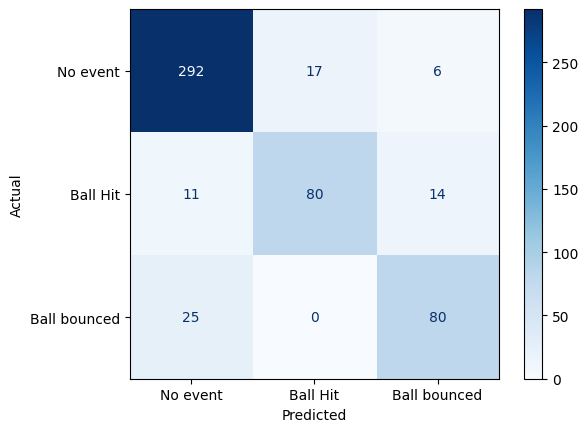

In [225]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=val_metrics['confusion_matrix'], display_labels=['No event', 'Ball Hit' , 'Ball bounced'])
disp.plot(cmap='Blues')
plt.xlabel('Predicted') and plt.ylabel('Actual')

In [ ]:
checkpoint = torch.load(
    "best_model.pt",
    map_location=device,
)

model.load_state_dict(
    checkpoint["model"]
)

print(
    checkpoint["f1"]
)